# 01 — Exploratory Data Analysis

Ames, Iowa housing (Kaggle *House Prices*), prices in **USD**.
To avoid peeking at the test set, EDA uses **the training split only** (80%, `random_state=42`, from `src.data.split_data`).

In [1]:
import sys; sys.path.insert(0, "..")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from src.data import load_data, split_data
from src.plotting import usd_k, setup_style, legend_outside, BLUE, RED, GREEN

setup_style()
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)

df = load_data()
X_train, X_test, y_train, y_test = split_data(df)
train = X_train.assign(SalePrice=y_train)
print("full:", df.shape, "| train:", train.shape, "(test is not used here)")

full: (1460, 81) | train: (1168, 80) (test is not used here)


## 1. Target distribution

count      1168.0
mean     181442.0
std       77264.0
min       34900.0
25%      130000.0
50%      165000.0
75%      214925.0
max      745000.0

skew raw   : 1.74
skew log1p : 0.12


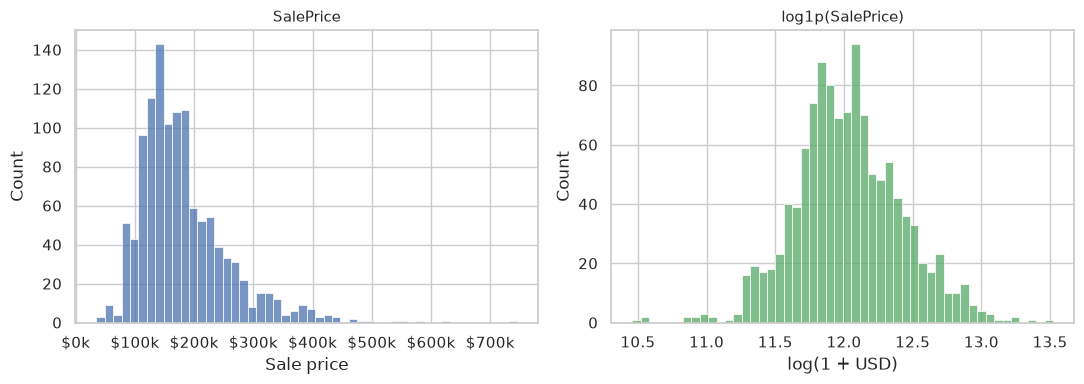

In [2]:
print(y_train.describe().round(0).to_string())
print(f"\nskew raw   : {y_train.skew():.2f}")
print(f"skew log1p : {np.log1p(y_train).skew():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(y_train, bins=50, ax=ax[0], color=BLUE); ax[0].set_title("SalePrice"); ax[0].xaxis.set_major_formatter(usd_k)
sns.histplot(np.log1p(y_train), bins=50, ax=ax[1], color=GREEN); ax[1].set_title("log1p(SalePrice)")
ax[0].set_xlabel("Sale price"); ax[1].set_xlabel("log(1 + USD)")
plt.tight_layout(); plt.savefig(FIG / "01_target_distribution.png", dpi=130); plt.show()

**Why log1p the target:** raw prices are right-skewed (a few mansions pull the tail), so squared-error models are dominated by expensive houses and the errors are multiplicative (a $20k miss on a $100k house is not the same as on a $500k house). `log1p` makes the distribution close to symmetric, makes errors relative, and matches Kaggle's metric (RMSLE = RMSE on log prices). Predictions are converted back with `expm1`.

## 2. Missing values — and what *missing* actually means

In [3]:
miss = train.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
meaning = {
 "PoolQC": "no pool", "MiscFeature": "no misc feature", "Alley": "no alley access",
 "Fence": "no fence", "MasVnrType": "REAL missing", "MasVnrArea": "REAL missing",
 "FireplaceQu": "no fireplace", "LotFrontage": "REAL missing",
 "GarageType": "no garage", "GarageYrBlt": "no garage", "GarageFinish": "no garage",
 "GarageQual": "no garage", "GarageCond": "no garage",
 "BsmtExposure": "no basement", "BsmtFinType2": "no basement", "BsmtFinType1": "no basement",
 "BsmtCond": "no basement", "BsmtQual": "no basement", "Electrical": "REAL missing",
}
tbl = pd.DataFrame({"n_missing": miss, "pct": (miss / len(train) * 100).round(1)})
tbl["meaning"] = [meaning.get(c, "?") for c in tbl.index]
print(tbl.to_string())
print("\nColumns with missing values:", len(tbl))

              n_missing   pct          meaning
PoolQC             1162  99.5          no pool
MiscFeature        1122  96.1  no misc feature
Alley              1094  93.7  no alley access
Fence               935  80.1         no fence
FireplaceQu         547  46.8     no fireplace
LotFrontage         217  18.6     REAL missing
GarageCond           64   5.5        no garage
GarageType           64   5.5        no garage
GarageYrBlt          64   5.5        no garage
GarageFinish         64   5.5        no garage
GarageQual           64   5.5        no garage
BsmtQual             28   2.4      no basement
BsmtCond             28   2.4      no basement
BsmtFinType1         28   2.4      no basement
BsmtExposure         28   2.4      no basement
BsmtFinType2         28   2.4      no basement
MasVnrType            6   0.5     REAL missing
MasVnrArea            6   0.5     REAL missing
Electrical            1   0.1     REAL missing

Columns with missing values: 19


Houses with PoolArea == 0     : 1162 | PoolQC NaN: 1162
Houses with GarageArea == 0   : 64 | GarageType NaN: 64
Houses with TotalBsmtSF == 0  : 28 | BsmtQual NaN: 28
Houses with Fireplaces == 0   : 547 | FireplaceQu NaN: 547


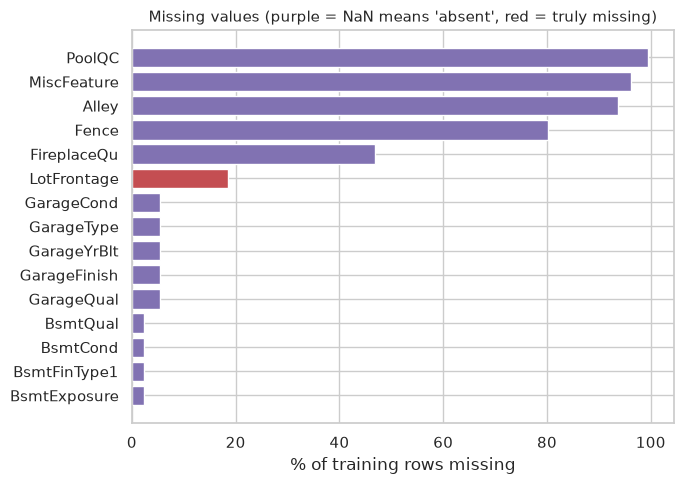

In [4]:
# sanity checks of the "NaN = feature absent" claim
print("Houses with PoolArea == 0     :", (train.PoolArea == 0).sum(), "| PoolQC NaN:", train.PoolQC.isna().sum())
print("Houses with GarageArea == 0   :", (train.GarageArea == 0).sum(), "| GarageType NaN:", train.GarageType.isna().sum())
print("Houses with TotalBsmtSF == 0  :", (train.TotalBsmtSF == 0).sum(), "| BsmtQual NaN:", train.BsmtQual.isna().sum())
print("Houses with Fireplaces == 0   :", (train.Fireplaces == 0).sum(), "| FireplaceQu NaN:", train.FireplaceQu.isna().sum())

top = tbl.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
colors = [RED if m == "REAL missing" else "#8172B2" for m in top.meaning]
ax.barh(top.index, top.pct, color=colors)
ax.set_xlabel("% of training rows missing"); ax.set_title("Missing values (purple = NaN means 'absent', red = truly missing)")
plt.tight_layout(); plt.savefig(FIG / "02_missing_values.png", dpi=130); plt.show()

**Takeaway:** most NaNs are *information* (NaN = the house has no pool / garage / basement / fireplace), not data errors. Filling them with the median/mode would be wrong; the categorical pipeline will fill them with the explicit category `"None"`. Only `LotFrontage`, `MasVnrType/Area` and `Electrical` are genuinely missing and get statistical imputation.

## 3. Top correlations with SalePrice

OverallQual     0.786
GrLivArea       0.696
GarageCars      0.641
GarageArea      0.624
TotalBsmtSF     0.598
1stFlrSF        0.588
FullBath        0.553
TotRmsAbvGrd    0.520
YearBuilt       0.517
YearRemodAdd    0.509
GarageYrBlt     0.480
MasVnrArea      0.459


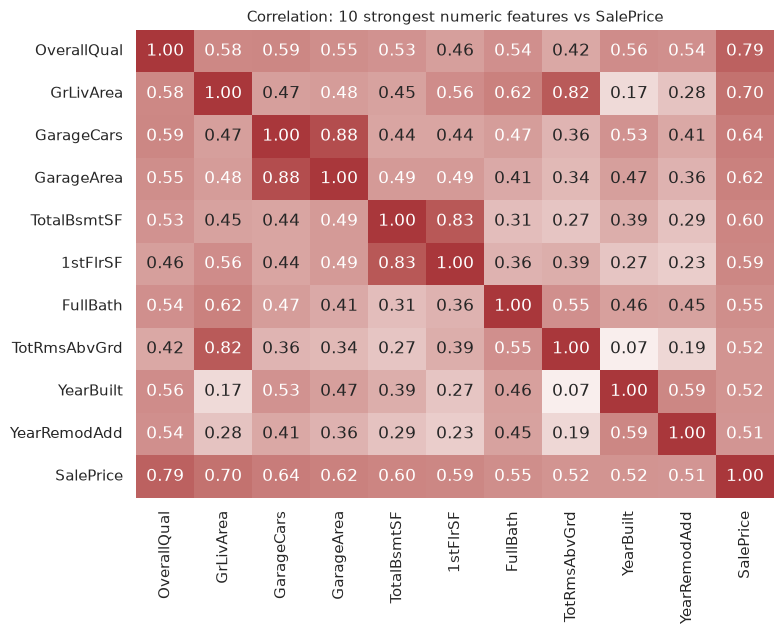

In [5]:
num = train.select_dtypes("number")
corr = num.corr()["SalePrice"].drop("SalePrice")
print(corr.reindex(corr.abs().sort_values(ascending=False).index).head(12).round(3).to_string())

top10 = corr.abs().sort_values(ascending=False).head(10).index.tolist()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(num[top10 + ["SalePrice"]].corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, cbar=False)
ax.set_title("Correlation: 10 strongest numeric features vs SalePrice")
plt.tight_layout(); plt.savefig(FIG / "03_correlations.png", dpi=130); plt.show()

Correlation is only **linear** association on numeric columns. `OverallQual` and `GrLivArea` lead. Several top features are collinear with each other (`GarageCars`/`GarageArea`, `TotalBsmtSF`/`1stFlrSF`) — relevant for linear models and for reading importances later. Categorical features such as `Neighborhood` are not in this view at all.

## 4. GrLivArea vs SalePrice — the known outliers

Outliers (GrLivArea > 4000 and SalePrice < $300k): 2
      GrLivArea  SalePrice  OverallQual SaleCondition Neighborhood
523        4676     184750           10       Partial      Edwards
1298       5642     160000           10       Partial      Edwards


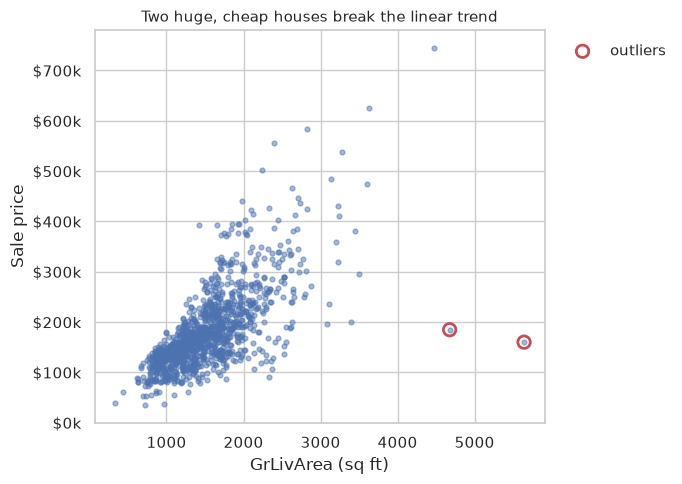

In [6]:
out = train[(train.GrLivArea > 4000) & (train.SalePrice < 300_000)]
print("Outliers (GrLivArea > 4000 and SalePrice < $300k):", len(out))
print(out[["GrLivArea", "SalePrice", "OverallQual", "SaleCondition", "Neighborhood"]].to_string())
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train.GrLivArea, train.SalePrice, s=12, alpha=.5, color=BLUE)
ax.scatter(out.GrLivArea, out.SalePrice, s=80, facecolors="none", edgecolors=RED, lw=2, label="outliers")
ax.set_xlabel("GrLivArea (sq ft)"); ax.set_ylabel("Sale price"); ax.yaxis.set_major_formatter(usd_k); legend_outside(ax)
ax.set_title("Two huge, cheap houses break the linear trend")
plt.tight_layout(); plt.savefig(FIG / "04_grlivarea_outliers.png", dpi=130); plt.show()

The documentation of the dataset (De Cock, 2011) itself warns about these houses: they are partial sales (`SaleCondition = Partial`) — unfinished or atypical sales, not normal market prices. We keep them in the data for now and **test removing them as an experiment in Stage 3**.

## 5. Houses per Neighborhood

Neighborhood
NAmes      181
CollgCr    115
OldTown     91
Edwards     87
Somerst     69
NWAmes      66
Gilbert     65
NridgHt     61
Sawyer      58
BrkSide     45
Crawfor     44
SawyerW     44
Mitchel     40
NoRidge     33
Timber      28
IDOTRR      26
SWISU       21
StoneBr     20
ClearCr     19
Blmngtn     15
BrDale      13
MeadowV     10
Veenker      9
NPkVill      7
Blueste      1

25 neighborhoods; median 40 houses; 7 neighborhoods have fewer than 20 training houses


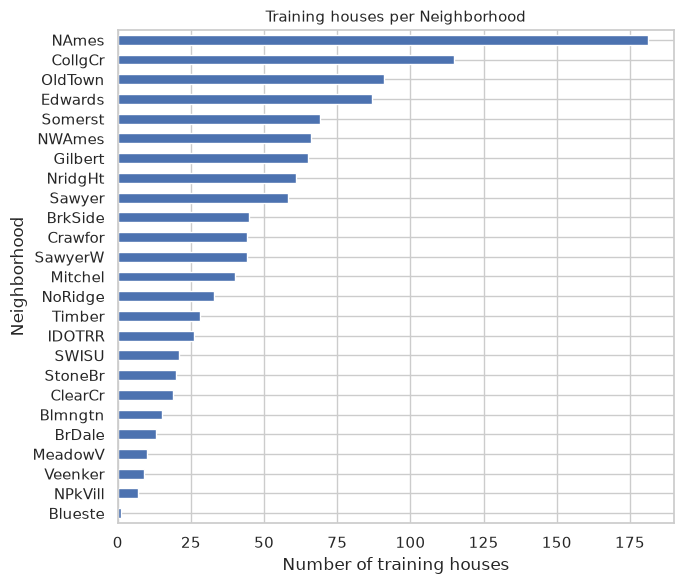

In [7]:
nb_counts = train.Neighborhood.value_counts()
print(nb_counts.to_string())
print(f"\n{len(nb_counts)} neighborhoods; median {nb_counts.median():.0f} houses; "
      f"{(nb_counts < 20).sum()} neighborhoods have fewer than 20 training houses")
fig, ax = plt.subplots(figsize=(7, 6))
nb_counts.iloc[::-1].plot.barh(ax=ax, color=BLUE)
ax.set_xlabel("Number of training houses"); ax.set_title("Training houses per Neighborhood")
plt.tight_layout(); plt.savefig(FIG / "05_neighborhood_counts.png", dpi=130); plt.show()

Data is very **unbalanced** across neighborhoods. This is the real version of the "bias" question: in Stage 4 we will *measure* whether the model's error is larger where there are few training houses, instead of assuming it.